<div class="output_png output_subarea output_execute_result">
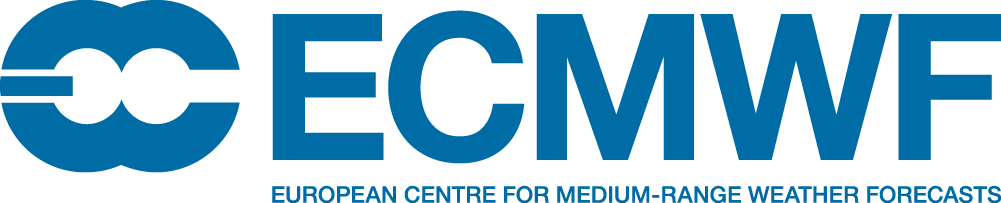
</div>

# AIFS ENS Control: Total cloud cover

This notebook will provide you with guidance on how to explore and plot the ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found at this link: https://charts.ecmwf.int/products/aifs_ens_cf_medium-clouds

<div class="output_png output_subarea output_execute_result">
<center>
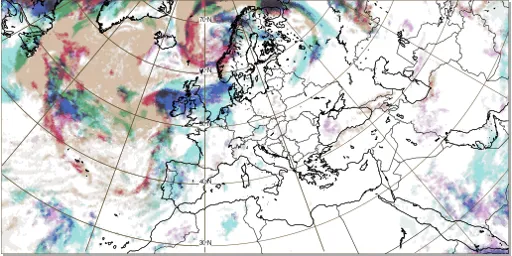</center>
</div>

A ‘synthetic’cloud field is defined as the combination of the three Low/Medium/High Cloud Cover, and a 64-colour table is associated with each value.

The full list of available AIFS Open data products can be found [here](https://www.ecmwf.int/en/forecasts/dataset/aifs-machine-learning-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS+from+IFS+and+AIFS).  

Access to ECMWF AIFS data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data 

This product takes in input 3 parameters : 
* [Low cloud cover](https://apps.ecmwf.int/codes/grib/param-db/?id=186)
* [Medium cloud cover](https://apps.ecmwf.int/codes/grib/param-db/?id=187)
* [High cloud cover](https://apps.ecmwf.int/codes/grib/param-db/?id=188)

In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read and process the data
- [**XArray**](https://docs.xarray.dev/en/stable/) library to perform computations
- [**Magics**](https://confluence.ecmwf.int/spaces/MAGP/pages/3473429/Magics) package to produce the visualisations

First we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [ ]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False, model="aifs-ens")

In [3]:
parameters = ['lcc', 'mcc','hcc']
filename = 'aifs_ens_cf_medium-clouds.grib'
filename

'aifs_ens_cf_medium-clouds.grib'

Setting date to 0 will download today's data. 
Removing date and time altogether from the request will download the latest data.  
Try commenting out date and time to download latest forecast!

In [4]:
client.retrieve(
    date=0,
    time=0,
    step=12,
    stream="enfo",
    type="cf",
    levtype="sfc",
    param=parameters,
    target=filename
)

20260729000000-12h-enfo-cf.grib2:   0%|          | 0.00/3.92M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


## Reading and processing the data
Now we can use **Metview's read() function** to read the files.

In [5]:
data = mv.read(filename)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,paramId,class,stream,type,experimentVersionNumber
hcc,highCloudLayer,450,20260729,0,12,3075,ai,enfo,cf,0001
lcc,lowCloudLayer,0,20260729,0,12,3073,ai,enfo,cf,0001
mcc,mediumCloudLayer,800,20260729,0,12,3074,ai,enfo,cf,0001


And an overview of one parameter, where we can see more information, such as units or type of level.

In [7]:
data.describe('lcc')

shortName,lcc
name,Low cloud cover
paramId,3073
units,%
typeOfLevel,lowCloudLayer
level,0
date,20260729
time,0
step,12
class,ai
stream,enfo


We can use **ls()** function to list all the fields in the file we downloaded.

In [8]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,gridType
Message,,,,,,,,,
0,ecmf,lcc,lowCloudLayer,0,20260729,0,12,cf,regular_ll
1,ecmf,mcc,mediumCloudLayer,800,20260729,0,12,cf,regular_ll
2,ecmf,hcc,highCloudLayer,450,20260729,0,12,cf,regular_ll


## Compute the synthetic cloud layer 
We perform a simple computation 
and save the result in a new netcdf *aifs_ens_cf_medium-clouds-combined.nc*

In [9]:
import xarray as xr

cloud = data.to_dataset()
colour_resol = 4
lcc = cloud["lcc"].values/100  * (colour_resol-1) + 0.5
lcc = lcc.astype(int)
mcc = cloud["mcc"].values/100  * (colour_resol-1) + 0.5
mcc = mcc.astype(int)
hcc = cloud["hcc"].values/100  * (colour_resol-1) + 0.5
hcc  = hcc.astype(int)
combined = (colour_resol*colour_resol)*hcc+(colour_resol * mcc)+lcc
combined = xr.Dataset(
    {
         "combined": (
             ("latitude", "longitude"),
             combined
         ),
         "latitude": cloud.latitude,
         "longitude": cloud.longitude
     }
    
 )
combined.to_netcdf("aifs_ens_cf_medium-clouds-combined.nc")
combined

<xarray.Dataset> Size: 8MB
Dimensions:           (latitude: 721, longitude: 1440)
Coordinates:
  * latitude          (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude         (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    number            int64 8B 0
    time              datetime64[ns] 8B 2026-07-29
    step              timedelta64[ns] 8B 12:00:00
    lowCloudLayer     float64 8B 0.0
    valid_time        datetime64[ns] 8B 2026-07-29T12:00:00
    mediumCloudLayer  float64 8B 800.0
    highCloudLayer    float64 8B 450.0
Data variables:
    combined          (latitude, longitude) int64 8MB 59 59 59 59 59 ... 0 0 0 0

## Use Magics to visualise the data 

[Magics](https://confluence.ecmwf.int/display/MAGP/Magics) is a visualisation package specialised in meteorological visualisation. 
Its simple interface allows to quickly visualise GRIB and NetCDF data on any geographical area and a large variety of projections.

Magics can be installed from PyPI  
`pip install magics`

In [11]:
from Magics import macro as magics
from ipywidgets import interact,Layout
import ipywidgets as widgets
import json


style = { 'description_width' : '200px'}
layout = Layout(width='600px')
largelayout = Layout(width='900px')

areas = magics.predefined_areas()


@interact(area = widgets.ToggleButtons( options=areas,
                            description='Geographical Area',
                            disabled=False, style = style, layout = largelayout, value = "europe"),
         )

def plot(area):
    cont_list = [-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,
             10.5,11.5,12.5,13.5,14.5,15.5,16.5,17.5,18.5,19.5,
             20.5,21.5,22.5,23.5,24.5,25.5,26.5,27.5,28.5,29.5,
             30.5,31.5,32.5,33.5,34.5,35.5,36.5,37.5,38.5,39.5,
             40.5,41.5,42.5,43.5,44.5,45.5,46.5,47.5,48.5,49.5,
             50.5,51.5,52.5,53.5,54.5,55.5,56.5,57.5,58.5,59.5,
             60.5,61.5,62.5,63.5]

    col_list=['HSL(0,0,1)','HSL(29,0.12,0.92)','HSL(29,0.23,0.83)','HSL(29,0.35,0.75)',
            'HSL(300,0.12,0.92)','HSL(344,0.17,0.84)','HSL(2,0.26,0.75)','HSL(10,0.37,0.67)',
            'HSL(300,0.23,0.83)','HSL(326,0.26,0.75)','HSL(344,0.34,0.67)','HSL(355,0.43,0.58)',
            'HSL(300,0.35,0.75)','HSL(318,0.37,0.67)','HSL(333,0.43,0.58)','HSL(344,0.5,0.5)',
            'HSL(180,0.17,0.92)','HSL(138,0.08,0.84)','HSL(70,0.12,0.75)','HSL(50,0.22,0.67)',
            'HSL(223,0.15,0.84)','HSL(262,0.04,0.75)','HSL(7,0.1,0.67)','HSL(19,0.21,0.59)',
            'HSL(256,0.21,0.75)','HSL(289,0.16,0.67)','HSL(330,0.18,0.58)','HSL(352,0.26,0.5)',
            'HSL(271,0.3,0.67)','HSL(294,0.27,0.59)','HSL(318,0.29,0.5)','HSL(337,0.34,0.42)',
            'HSL(180,0.34,0.83)','HSL(166,0.24,0.75)','HSL(138,0.17,0.67)','HSL(99,0.17,0.58)',
            'HSL(199,0.29,0.75)','HSL(194,0.18,0.67)','HSL(169,0.07,0.58)','HSL(67,0.08,0.5)',
            'HSL(223,0.3,0.67)','HSL(231,0.19,0.58)','HSL(262,0.09,0.5)','HSL(339,0.1,0.42)',
            'HSL(242,0.34,0.58)','HSL(256,0.25,0.5)','HSL(283,0.2,0.42)','HSL(317,0.2,0.33)',
            'HSL(180,0.5,0.75)','HSL(171,0.4,0.67)','HSL(158,0.32,0.58)','HSL(138,0.26,0.5)',
            'HSL(192,0.45,0.67)','HSL(187,0.34,0.59)','HSL(176,0.24,0.5)','HSL(152,0.15,0.42)',
            'HSL(207,0.43,0.58)','HSL(207,0.32,0.5)','HSL(206,0.2,0.42)','HSL(203,0.08,0.33)',
            'HSL(223,0.44,0.5)','HSL(227,0.33,0.42)','HSL(237,0.22,0.33)','HSL(262,0.13,0.25)']

    area = magics.mmap(
        subpage_map_library_area = "on",
        subpage_map_area_name    = area,
        page_id_line             = "off"
    )




    data = magics.mnetcdf(netcdf_filename = "aifs_ens_cf_medium-clouds-combined.nc",
                      netcdf_value_variable = "combined")

    contour = magics.mcont(
            legend                          = 'on',
            contour_shade                   = 'on',
            contour                         = 'off',
            contour_level_selection_type    = 'list',
            contour_level_list              =  cont_list,
            contour_shade_colour_list       =  col_list,
            contour_shade_colour_method     = 'list',
            contour_shade_technique         = 'cell_shading',
            contour_shade_cell_method       = 'nearest',
            contour_hilo                    = 'off',
            contour_shade_cell_resolution   = 20.0
            )

    legend = magics.mlegend(legend_display_type = "continuous", 
                            legend_text_font_size=0.3,
                            legend_text_colour ='navy')
    text ="<font color='{}'>Low,</font> \
    <font color={}>L+M,</font> \
    <font color={}>Medium,</font> \
    <font color={}>M+H,</font> \
    <font color={}>High,</font>\
    <font color={}>H+L,</font>\
    <font color={}>H+M+L </font> clouds".format(col_list[4], col_list[16], col_list[13], col_list[61],col_list[49], col_list[52], "black")
   
    title = magics.mtext(
                    text_line_count    = 1,
                    TEXT_FONT_SIZE     = 0.40,
                    TEXT_JUSTIFICATION = 'LEFT',
                    text_line_1       = ' ECMWF AIFS ENS Control Clouds  ',
                    text_line_2     = text 
                   )

    return magics.plot(area, data, contour, legend, title, magics.mcoast())

interactive(children=(ToggleButtons(description='Geographical Area', index=9, layout=Layout(width='900px'), op…